# **1. Perkenalan Dataset**


1. **Sumber Dataset**:  
  - Dataset yang digunakan ini adalah **Tokopedia Product Reviews 2019** yang didapat dari Kaggle.
  - **Sumber**: https://www.kaggle.com/datasets/farhan999/tokopedia-product-reviews
  - **Fitur utama**:
    - `text`: Teks ulasan konsumen dalam bahasa Indonesia
    - `rating`: Rating dari sebuah produk dari 1 sampai 5
    - `category`: Kategori dari sebuah produk
    - `product_name`: Nama produk atau barang
    - `product_id`: ID produk
    - `sold`: Jumlah produk yang sudah terjual
    - `shop_id`: ID toko yang menjual produk atau barang
    - `product_url`: URL produk untuk memudahkan pencarian
  
  - **Task**: Sentiment Analysis (Klasifikasi)
    - Rating 4 - 5 -> **Positif**
    - Rating 3 -> **Netral**
    - Rating 1 - 2 -> **Negatif**


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [34]:
# import libary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from google.colab import drive

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Sklearn
from sklearn.preprocessing import LabelEncoder

# download NLTK resource
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print ("semua libary berhasil di import")

semua libary berhasil di import


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [35]:
# memuat dataset dari google drive
drive.mount('/content/drive')

# load dataset
df = pd.read_csv('/content/drive/MyDrive/Proyek-Akhir-MSML/tokopedia-product-reviews-2019.csv')

# menampilkan data
print("Shape dataset:", df.shape)
print("\n5 baris pertama:")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape dataset: (40607, 9)

5 baris pertama:


,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - S...,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staple...
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; O...,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-stap...
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gu...,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-ref...


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [36]:
# info dataset
print("INFO DATASET")
print(df.info())

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    40607 non-null  int64 
 1   text          40607 non-null  object
 2   rating        40607 non-null  int64 
 3   category      40607 non-null  object
 4   product_name  40607 non-null  object
 5   product_id    40607 non-null  int64 
 6   sold          40593 non-null  object
 7   shop_id       40607 non-null  int64 
 8   product_url   40607 non-null  object
dtypes: int64(4), object(5)
memory usage: 2.8+ MB
None


In [37]:
# statistik deskriptif
print("STATISTIK DESKRIPTIF")
print(df.describe(include='all'))

STATISTIK DESKRIPTIF
          Unnamed: 0                     text        rating    category  \
count   40607.000000                    40607  40607.000000       40607   
unique           NaN                    37301           NaN           5   
top              NaN  Barang sesuai deskripsi           NaN  elektronik   
freq             NaN                       57           NaN       15897   
mean    20443.690103                      NaN      4.642574         NaN   
std     11810.534919                      NaN      0.732448         NaN   
min         1.000000                      NaN      1.000000         NaN   
25%     10225.500000                      NaN      4.000000         NaN   
50%     20427.000000                      NaN      5.000000         NaN   
75%     30680.500000                      NaN      5.000000         NaN   
max     40893.000000                      NaN      5.000000         NaN   

                                             product_name    product_id  \
cou

In [38]:
# mengecek missing values
print("MISSING VALUES")
print(df.isnull().sum())

MISSING VALUES
Unnamed: 0       0
text             0
rating           0
category         0
product_name     0
product_id       0
sold            14
shop_id          0
product_url      0
dtype: int64


In [39]:
# mengecek duplikat
print("DUPLIKAT")
print(f"Jumlah data yang duplitkat: {df.duplicated().sum()}")

DUPLIKAT
Jumlah data yang duplitkat: 0


/tmp/ipykernel_4939/3523786972.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


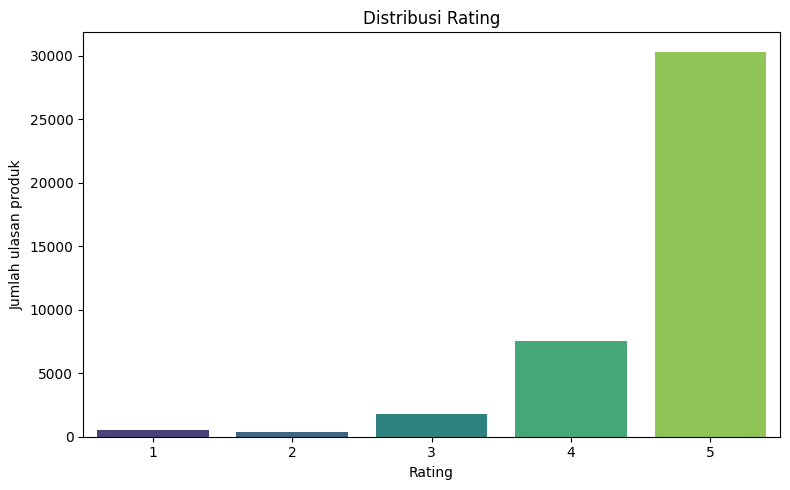

In [40]:
# distribusi rating
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribusi Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah ulasan produk')
plt.tight_layout()
plt.show()

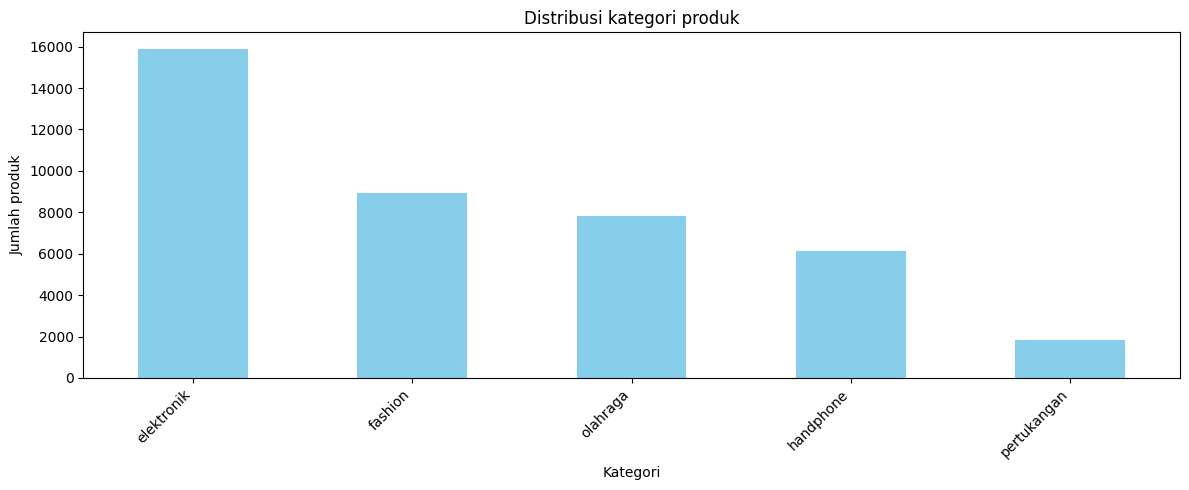

In [41]:
# distribusi kategori
plt.figure(figsize=(12, 5))
df['category'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Distribusi kategori produk')
plt.xlabel('Kategori')
plt.ylabel('Jumlah produk')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

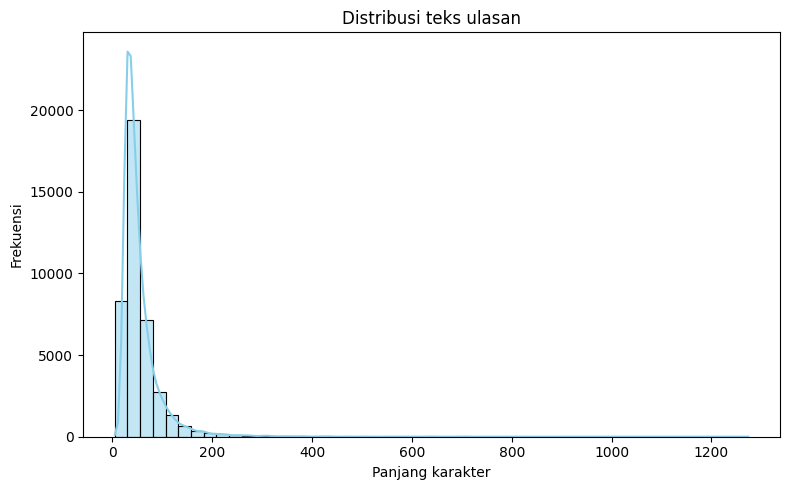

In [42]:
# teks ulasan
df['text_length'] = df['text'].astype(str).apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribusi teks ulasan')
plt.xlabel('Panjang karakter')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

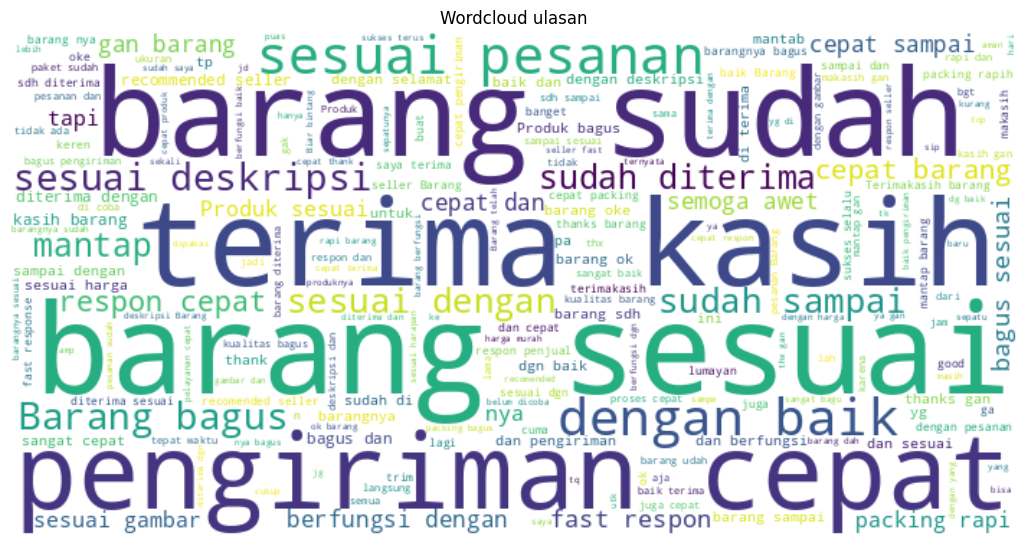

In [43]:
# wordcloud ulasan
from wordcloud import WordCloud
text_all = ' '.join(df['text'].astype(str).tolist())
wordcloud = WordCloud(width=700, height=350, background_color='white').generate(text_all)
plt.figure(figsize=(13, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud ulasan')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [44]:
# memilih kolom yang relavan
df_clean = df[['text', 'rating']].copy()

# drop missing value
df_clean.dropna(subset=['text', 'rating'], inplace=True)
print(f"Shape setelah drop NA: {df_clean.shape}")

Shape setelah drop NA: (40607, 2)


In [45]:
# drop duplikat
df_clean.drop_duplicates(inplace=True)
print(f"Shape setelah drop duplikat: {df_clean.shape}")

# hapus ulasan yang sangat pendek
df_clean = df_clean[df_clean['text'].astype(str).apply(len) >= 3]
print(f"Shape setelah hapus teks terpendek: {df_clean.shape}")

Shape setelah drop duplikat: (37669, 2)
Shape setelah hapus teks terpendek: (37669, 2)


In [46]:
# konversi rating ke label sentimen
def rating_to_sentiment(rating):
  if rating >= 4:
    return 'Positif'
  elif rating == 3:
    return 'Netral'
  else:
    return 'Negatif'

df_clean['sentiment'] = df_clean['rating'].apply(rating_to_sentiment)
print(df_clean['sentiment'].value_counts())

sentiment
Positif    34955
Netral      1798
Negatif      916
Name: count, dtype: int64


In [47]:
# teks cleaning
def clean_text(text):
  text = str(text).lower()  #lowercase
  text = re.sub(r'\d+', '', text) #menghapus angka`
  text = text.translate(str.maketrans('', '', string.punctuation))  #menghapus tanda baca
  text = re.sub(r'\s+', ' ', text).strip()  #menghapus spasi yang berlebih
  return text

df_clean['text_clean'] = df_clean['text'].apply(clean_text)

# menghapus stopwords
stop_words = set(stopwords.words('indonesian'))

def remove_stopwords(text):
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word not in stop_words]
  return ' '.join(tokens)

df_clean['text_clean'] = df_clean['text_clean'].apply(remove_stopwords)

In [48]:
# label encoding
le = LabelEncoder()
df_clean['sentiment_encoded'] = le.fit_transform(df_clean['sentiment'])
print("Label Encoding:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


print("Preview hasil preprocessing")
print(df_clean[['text', 'text_clean', 'sentiment', 'sentiment_encoded']].head())

# menyimpan hasil
output_path = '/content/drive/MyDrive/Proyek-Akhir-MSML/tokopedia-preprocessing.csv'
df_clean.to_csv(output_path, index=False)
print(f"Dataset preprocessing berhasil disimpan di: {output_path}")

Label Encoding:
{'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}
Preview hasil preprocessing
                                              text  \
0           Barang sesuai pesanan dan cepat sampai   
1                         Barang bagus harga murah   
2  Paket rapi...mantap....cepat....sampe ke tujuan   
3                       ya saya puas dgn barangnya   
4                     Responya luar biasa b mantap   

                          text_clean sentiment  sentiment_encoded  
0        barang sesuai pesanan cepat   Positif                  2  
1           barang bagus harga murah   Positif                  2  
2  paket rapimantapcepatsampe tujuan   Positif                  2  
3              ya puas dgn barangnya   Positif                  2  
4                  responya b mantap   Positif                  2  
Dataset preprocessing berhasil disimpan di: /content/drive/MyDrive/Proyek-Akhir-MSML/tokopedia-preprocessing.csv
